## Homework 05 - due Friday, March 6th by 4 PM 

Name: Kristen Townsend

In [1]:
from gaussxw import gaussxw
import math
import numpy as np
import matplotlib.pyplot as plt

### Problem 1: Exercise 5.12, page 173

Part a

I began with the equation for thermal energy radiated by a black body $I(\omega) = \frac{\hbar}{4\pi^2 c^2} \frac{\omega^3}{(e^{\hbar\omega / k_b T} - 1)}$, where $\hbar$ is reduced Plank's constant, $c$ is the speed of light, and $k_B$ is Boltzmann's constant.

To find the total rate at which energy is radiataed by a black body per unit area, I pulled out any constants and integrated:

$\int I(\omega) = \frac{\hbar}{4\pi^2 c^2} \int \frac{\omega^3}{(e^{\hbar\omega / k_b T} - 1)}$

I then performed a u-substitution so $u = \frac{\hbar \omega}{k_b T}$ and $du = \frac{\hbar}{k_b T} d\omega$. Solving for $\omega$ gives $\omega = \frac{k_B T}{\hbar} u$ and $d\omega = \frac{k_B T}{\hbar} du$.

Substituting the answer found for $\omega$ into the original equation gives $\omega^3 = \left(\frac{k_B T}{\hbar}\right)^3 u^3 $. These constants are then pulled from the integral.

The integration occurs over all possible values $[0, \infty)$. Finally, I replaced all u's with x's to remain consistent with the notiation within the book, resulting in:

$$W = \frac{k_B^4 T^4}{4\pi^2 c^2 \hbar^3} \int_{0}^{\infty} \frac{x^3}{e^x - 1} dx $$

In [2]:
# part (b)
# do the integration first
# defining the part being integrated as a function
def int_W(z):
    # breaking down the function to avoid mis-types
    u = z / (1-z)

    # avoid overflow in exp
    if u > 1000:
        return 0.0

    a = u**3
    b = np.expm1(u)
    c = 1 / (1-z)**2
    return (a/b)*c

# applying gaussean quadrature
# integration constants
step_N = 50
low = 0.0
high = 1.0
x1, w1 = gaussxw(step_N, low, high)

s = 0.0
for k in range(step_N):
    s += w1[k]*int_W(x1[k])

# printing results
print("Integral result:", s)


Integral result: 6.493939400514868


In [3]:
# part c
# defining other constants
k_B = 1.380649e-23
light_c = 299792458
hbar = 1.0545718e-34

T = 1 # up to me to define, I believe

# finding W from book equation for total rate emitted
W = ((k_B**4 * T**4) / (4 * math.pi**2 * light_c**2 * hbar**3)) * s

# solving for the Stefan-Boltzmann constant
SB_const = W / T**4

# printing results to 3 sig-figs
print("My Stefan-Boltzmann constant:", f"{SB_const:.2e}")



My Stefan-Boltzmann constant: 5.67e-08


##### Explanation: 

To complete the necessary integral in part (b), I imported the gaussxw.py file for gaussian quadrature and also imported math.

Because this integration went from $[0,\infty)$, the following change of variables was required: $x = \frac{z}{1-z}$ and $dx = \frac{dz}{(1-z)^2}$. These changes were used within the function definition of the integrand. The function also includes a preventitive measure against overflow by returning the value zero if the substituted value becomes too large, as there is an exponent in the denominator that will quickly collapse the value to be incredibly small.

The integral then becomes 
$$\int_{0}^{1} \frac{\left(\frac{z}{1-z}\right)^3}{e^{\frac{z}{1-z}} -1} \frac{1}{(1-z)^2} dz $$

I then applied Gaussian Quadrature by establishing my integration bounds and step size, and then calculating the sample points and their respective weights using the gaussxw.py file that is imported into the notebook above.

After summing over all of the calculations $w[k] f(x[k])$ for k by iterating through all values of N-1, the summation result was then printed.

I believe this answer is decently accurate, as Gaussian quadrature as a integration method is highly accurate. Gaussian quadrature optimizes both every evaluation point and their weights instead of evenly spacing them like for Simpson's rule.

Part (c) was delightfully straight-forward. I first completed the calculation for $W$ shown above by multiplying the integral result by the amalgamation of constants in front of it.

I then used used $W = \sigma T^4$ to solve for Stefan-Boltzmann constant $\sigma$. With the previously found $W$ and $T$, I found my Stefan-Boltzmann constant to be equal to $5.67\times 10^{-8}$

$\sigma$ is generally accepted to be equal to $5.67\times 10^{-8}$. Those look the same to me!

### Problem 2: Exercise 5.14, page 178

To determine the gravitational force component acting on the point mass for part (a), I began by taking a small area of the plate $dA = dx dy$ and the corresponding mass for that small area $dm = \sigma dx dy$. The distance from this small area to the mass located at $(0,0,z)$ is $r = \sqrt{x^2 + y^2 + z^2}$. 

Newton's Law of Gravitation $F = G \frac{m_1 m_2}{r^2}$ can then be used to find the force on the point mass from the small element
$$dF = G \frac{(1)(dm)}{r^2},$$
$$dF = G \frac{\sigma dx dy}{r^2},$$
with $m_1 = 1$ kg as specified in the problem and $m_2 = dm$.

I then found the direction of the force $\vec{r} = \left< x, y, -z \right>$ acting on the point mass and the associated unit vectors $\hat{r} = \frac{\left< x, y, -z \right>}{r}$. I then multiplied the unit vectors by the force to include the *direction* of the gravitaional force on the magnitude, resulting in:

$$d\vec{F_z} = \frac{G\sigma dx dy}{r^2} \frac{\left< x, y, -z \right>}{r}. $$

The x and y components cancel due to symmetry, leaving:

$$d\vec{F_z} = \frac{G\sigma dx dy}{r^3} \left(-z\right).$$

However, because the problem is only looking for the magnitude of the force, take the absolute value to get:
$$d\vec{F_z} = \frac{G\sigma dx dy}{r^3} \left(z\right)$$

Finally, integrate x and y over the square plate $x = [\frac{L}{2}, -\frac{L}{2}]$ and $y = [\frac{L}{2}, -\frac{L}{2}]$, thus showing that the component of force along the z-axis is

$$F_z = G\sigma z \int_{\frac{-L}{2}}^{\frac{L}{2}} \int_{\frac{-L}{2}}^{\frac{L}{2}} \frac{dx dy}{(x^2 + y^2 + z^2)^{3/2}} .$$




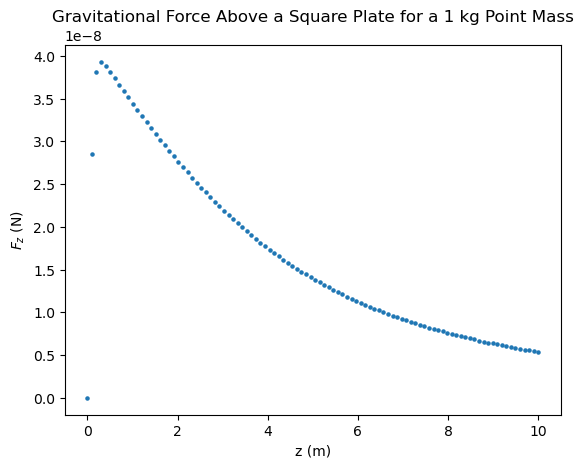

In [4]:
# part b
# define the integrand as a function
def grav_func(x, y, z):
    return 1 / (x**2 + y**2 + z**2)**(3/2)

# Gaussian quadrature
# integration constants
G = 6.674e-11 # gravitational constant
sigma = 0.1 * 1000# metric ton, converted to kg, mass per unit area

step_N = 50
L = 10 # meters, side length

# integration bounds
a_grav = -L/2 # m
b_grav = L/2 # m

# points and weights
x_grav, w_grav = gaussxw(step_N, a_grav, b_grav) # x and y have same bounds

# make an array of z-values and eventual force values
z_vals = np.linspace(1e-10, 10, 100) # 100 pts along axis
F_vals = np.zeros(len(z_vals))

# fill in the forces
for k in range(len(z_vals)):
    # reset summation for every z-value
    s = 0.0
    # 2D grid
    for i in range(step_N):
        for j in range(step_N):
            # x and y are the same, can re-use points and weights arrays
            s += w_grav[i]*w_grav[j] * grav_func(x_grav[i], x_grav[j], z_vals[k])

    F_vals[k] = G * sigma * z_vals[k] * s

# plotting time
plt.scatter(z_vals, F_vals, s=5)

plt.xlabel("z (m)")
plt.ylabel("$F_z$ (N)")
plt.title("Gravitational Force Above a Square Plate for a 1 kg Point Mass")

plt.show()

#### Explanation: 

For part (b) I completed the integral above using double Gaussian quadrature with 100 sample points along each axis, as detailed in the book. To make my life much easier later on, I defined the integrand as a function. Because x and y are integrated along the same bounds, I was able to make one set of arrays with the gaussxw() function and re-use them for both values.

I established integration bounds, other constants, an array of 100 z-points from zero to 10 to be integrated with, and an array to be filled with force values.

I integrated using the summation $\Epsilon_{i=1}^{N} \Epsilon_{j=1}^{N} w_i w_j f(x_i, y_j)$ and multiplied each force value by the remnants of the equation above which live outside of the integral.

Once I had found every force value, I imported matplotlib.pyplot above and made a scatter plot with the force values and z-values, and it resulted in a really interesting curve as the distance between the plate and the point mass increased! Labels were added for clarity.


I believe the drop off at the beginning of the plot and discussed in part (c) occurs due to the behavior of the integrand $\frac{1}{(x^2 + y^2 + z^2)^{3/2}}$. When z becomes negligibly small, the denominator reaches incredibly close to zero. Because x and y are both equal to zero at the origin the integrand begins to behave like $\frac{1}{z^3}$. 

To avoid the aggressive drop-off, I could increase my number of steps to give more data points near the center. I could also just avoid extremely small z values by beginning my evaluation at a higher value like $z=0.1$.

### Problem 3: Exercise 5.16, page 184

In [5]:
# all the functions
# define a random function to apply derivative techniques on
def rand_func(x):
    return math.sin(x)

# the real value
def real_deriv(x):
    return math.cos(x)

# forward difference
def calc_fd(f,x,h):
    fd = (f(x+h)-f(x))/h
    return fd

# central difference
def calc_cd(f,x,h):
    cd = (f(x+h/2)-f(x-h/2))/h
    return cd


# input values
h_vals = np.linspace(6.25, 6.3, 100) # create an array of h-values
x = 0.48 
true_val = real_deriv(x)

# define an array of forward difference values
fd_array = np.zeros(len(h_vals))

for j in range(len(fd_array)):
    fd_array[j] = calc_fd(rand_func, x, h_vals[j])

# define an array of central difference values
cd_array = np.zeros(len(h_vals))

for k in range(len(cd_array)):
    cd_array[k] = calc_cd(rand_func,x,h_vals[k])

# forward error
fd_error = np.abs(fd_array - true_val)

# central error
cd_error = np.abs(cd_array - true_val)

# printing results
print("The true derivative is", true_val)
print(" h          forward error        central error")
rowf = "{0:1.4e} {1:1.16f} {2:1.16f}"

for i in range(len(h_vals)):
    print(rowf.format(h_vals[i], fd_error[i], cd_error[i]))
    # checking if condition is met
    if fd_error[i] < cd_error[i]:
        print('THE SWITCH HAS OCCURED AT h =', h_vals[i])
        break

The true derivative is 0.8869949227792842
 h          forward error        central error
6.2500e+00 0.8917443697901378 0.8822855070459297
6.2505e+00 0.8916711257432292 0.8823575484234403
6.2510e+00 0.8915979111822990 0.8824295784554781
6.2515e+00 0.8915247261187789 0.8825015971402241
6.2520e+00 0.8914515705640916 0.8825736044758594
6.2525e+00 0.8913784445296515 0.8826456004605661
6.2530e+00 0.8913053480268653 0.8827175850925262
6.2535e+00 0.8912322810671310 0.8827895583699231
6.2540e+00 0.8911592436618389 0.8828615202909402
6.2545e+00 0.8910862358223701 0.8829334708537618
6.2551e+00 0.8910132575600989 0.8830054100565725
6.2556e+00 0.8909403088863906 0.8830773378975576
6.2561e+00 0.8908673898126021 0.8831492543749029
6.2566e+00 0.8907945003500826 0.8832211594867949
6.2571e+00 0.8907216405101726 0.8832930532314207
6.2576e+00 0.8906488103042046 0.8833649356069676
6.2581e+00 0.8905760097435035 0.8834368066116239
6.2586e+00 0.8905032388393846 0.8835086662435783
6.2591e+00 0.8904304976031565

#### Explanation: 

To find when the central difference becomes less accurate than the forward difference, I used the function $\sin(x)$ because a value can be found for all values of x, but higher order derivatives will not just reduce to zero. I thought it was more interesting. 

I created and filled arrays for both forward and central difference by defining a function for each process and applying them on my chosen function at $x = 0.48$. I chose a weirder value to avoid any derivative being a nice, easy number like 0 or 1. I initially had the inputted h-values ranging from 0.5 to 10, but I was then able to focus on the rough area the switch between accuracies occured for a higher accuracy on the h-value.

I then found the error of each difference technique by comparing them to the real derivative calculation. Once the error of the forward difference became smaller than the central difference, I broke the print statement.

The switch happens when $h \approx 6.283$. Any value above this h will also have a greater central difference error than forward difference error until the h-step becomes so large the difference is inconsequential because it's so vague and $\sin(x)$ continues in roughly the same 'plane' forever.



### Problem 4: Exercise 5.18, page 206

In [6]:
# define function with substitution for integration
def pi_guess(z):
    one = (z/(1-z))**2 + 1
    two = (1-z)**2
    return 1/one * 1/two

# adaptive sompsons rule on a to b with a tolerance
def adaptive_simpsons(pi_guess, a, b, tolerance): 
    # midpoint of a and b
    c = (a+b)/2

    # simpsons on the inverval a to b
    h = (b-a)/2
    S = (h/3) * (pi_guess(a) + 4*pi_guess(c) + pi_guess(b))

    # simpson on the left half, a to c
    h1 = (c-a)/2
    S1 = (h1/3) * (pi_guess(a) + 4*pi_guess((a+c)/2) + pi_guess(c))

    # simpson on the right half, c to b
    h2 = (b-c)/2
    S2 = (h2/3) * (pi_guess(c) + 4*pi_guess((c+b)/2) + pi_guess(b))

    # checking the error
    if np.abs((S1 + S2) - S) / 15 < tolerance:
        return S1 + S2 
    else:
        # split again
        return adaptive_simpsons(pi_guess, a, c, tolerance/2) + adaptive_simpsons(pi_guess, c, b, tolerance/2)


# computing pi
# bounds
a = 0
b = 1 - 1e-12 # diverges at 1, want to aboid any overflow
tolerance = 1e-11 # we want about 10 decimal places accuracy

result = adaptive_simpsons(pi_guess, a, b, tolerance) # estimate to pi/2

pi_est = 2 * result

print("Actual value of pi:   ", f"{math.pi: .10f}")
print("Estimated value of pi:", f"{pi_est: .10f}")
print("We're looking at an error of", pi_est - np.pi, "\nThat's basically zero!")

Actual value of pi:     3.1415926536
Estimated value of pi:  3.1415926536
We're looking at an error of -2.8377300509419e-12 
That's basically zero!


#### Explanation:

We know that $\int_{0}^{\infty} \frac{dx}{x^2 +1} = \frac{\pi}{2}$. Because this integral goes from 0 to $\infty$, we can use the substitution $x = z / 1-z$ to perform the integration.

I completed this integral using an adaptive Simpson's law. It works by continually segmenting the function for summations. If the accuracy for a 'chunk' is too low, it is split in half and the process repeats until the desired accuracy is reached.

If the error approximation of $\delta = \frac{1}{15}|I_2 - I_1|$ where $I_2$ is the summation of the half estimates and $I_1$ is the estimate of the entire section. If this error is within the tolerance specified, in this case 1e-11, the value is accepted. If not, the process repeats for both halves.

This results in a more detailed summation when the integrand is changing quickly, and a less detailed summation for the rest of the integrand.

### Problem 5: Exercise 5.24, page 210

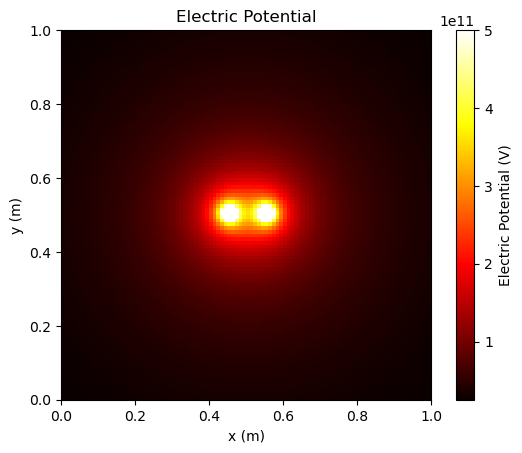

In [7]:
# part a
# define an electric potential function
def elec_pot(r, q):
    permit = 8.854187e-12 # permittivity of free space
    return q / (4 * math.pi * permit * r)

# physical constants
separation = 0.1 # of the two charges in meters
side = 1.0 # of the square
points = 100 # number of grid points along each side
spacing = side/points #spacing of points

charge = 1 # Coulomb

# calculate positions of the charges
x1 = side/2 + separation/2
y1 = side/2
x2 = side/2 - separation/2
y2 = side/2

# make an array to store values
potential = np.zeros([points,points], float)

# calculate the values in the arrays
for i in range(points):
    y = spacing * i

    for j in range(points):
        x = spacing * j

        # distance from point charge to pixel
        r1 = max(math.sqrt((x-x1)**2 + (y-y1)**2), 1e-12) # avoids division by zero
        r2 = max(math.sqrt((x-x2)**2 + (y-y2)**2), 1e-12)

        potential[i,j] = elec_pot(r1, charge) + elec_pot(r2, charge)

# plotting the plot to look like a plot
plt.imshow(potential, origin="lower", extent=[0,side,0,side], vmax=5e11) # extent 'scales' it
plt.title("Electric Potential")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.hot()
plt.colorbar(label="Electric Potential (V)")

plt.show()


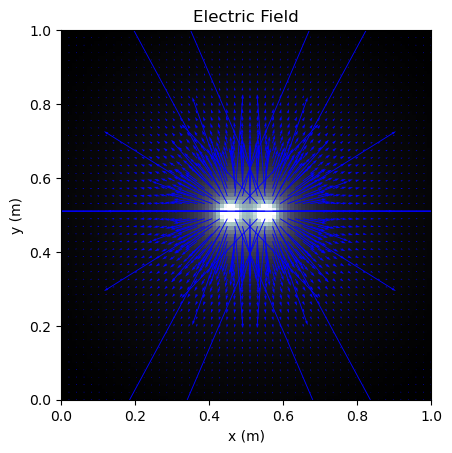

In [8]:
# part b

# electric potential with respect to x and y
def elec_pot_xy(x, y, q):
    permit = 8.854187e-12 # permittivity of free space
    
    # two points!
    r1 = max(math.sqrt((x-x1)**2 + (y-y1)**2), 1e-12) # avoids division by zero
    r2 = max(math.sqrt((x-x2)**2 + (y-y2)**2), 1e-12)
    
    return q / (4 * math.pi * permit * r1) + q / (4 * math.pi * permit * r2)


points = 50 # number of grid points along each side
spacing = side/points #spacing of points


# make a arrays to store values
Ex = np.zeros([points,points]) # x-partial
Ey = np.zeros([points,points]) # y-partial

h = 1e-8

# calculate the values in the arrays
for i in range(points):
    y = spacing * i

    for j in range(points):
        x = spacing * j

        # derivative with respect to x
        pot_xplus = elec_pot_xy(x+h/2, y, charge)
        pot_xminus = elec_pot_xy(x-h/2, y, charge)
        # applying central difference
        dpsidx = (pot_xplus - pot_xminus) / h 

        # derivative with respect to x
        pot_yplus = elec_pot_xy(x, y+h/2, charge)
        pot_yminus = elec_pot_xy(x, y-h/2, charge)
        # applying central difference
        dpsidy = (pot_yplus - pot_yminus) / h

        # applying electric field equation makes the deriv's negative
        Ex[i,j] = -dpsidx
        Ey[i,j] = -dpsidy

# stack the potentials underneath so it's more obvious
plt.imshow(potential, origin="lower", extent=[0,side,0,side], vmax=5e11) # extent 'scales' it
plt.bone()

# using the quiver function, as mentioned in the book
# need a 2D grid of points for this to work
X, Y = np.meshgrid(np.linspace(0, side, points), np.linspace(0, side, points))

plt.quiver(X, Y, Ex, Ey, scale=2e13, color="blue") # scale is necessary for anything interesting
plt.title("Electric Field")
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.show()

#### Explanation: 

For part (a), we need to calculate the electric potential from two point charges on a 1 meter by 1 meter square. I was able to reference the interference plot we were working with a few weeks ago, which was incredibly helpful for determining the geometery I was working with.

I defined an equation dependant on the charge q and radius r which would return the electric potential of a point on a grid of matrices following

$$\phi = q / 4 \pi \epsilon_0 r$$

Because this would result in a density plot, I created an empty 2D matrix and filled in each value with nested for loops.

As there were two point charges involved, the radius from each to the array index had to calculated individually. The potentials were then superimposed together and inserted into the array.

Because the potential is so high close to the charges I limited the maximum value to make the decrease of electric potential over distance visible. I chose the 'hot' color scheme because it works well with the decrease and it looks like car headlights and I thought that was funny.


For part (b), to find the electric field $E = - \nabla \phi$ at each point in the array I needed to find the partial derivative E with respect to x and the partial derivative of E with respect to y.

I redefined a function for the electric potential to rely on x and y as an input, as both directions are needed later for the quiver function when plotting. The function now depends on the relationship $r = \sqrt{x^2 + y^2}$.

Within a nested for loop I applied the central difference method to find the derivative with respect for a specific variable while treating the other as a constant. I then repeated the process for the other variable. When the gradient of $\phi$ was complete I switched the sign to follow $E = - \nabla \phi$ and the loop continued iterating through values.

Once I had an array of Ex values and Ey values for the full grid, it was time to plot.

I was able to find the documentation for the quiver() function, and made a grid of values for the arrow bases using numpy's meshgrid() function. The points of the arrows then followed the Ex and Ey values for coordinates.

Purely for visuals I reduced the number of arrows and decreased the scaling so it wasn't just all blue and layered the previous potential density plot in the bone() color scheme underneath the blue arrows. It is more physically interesting this way, and it's far easier to see how the two relate for any given value.

...and I could have done most of this with the numpy gradient() function, but I felt like that was not what you wanted us to do.